# Bayesian vs. Frequentist Analysis of Proportions
## California School Pass Rates (the `star98` dataset)

This notebook mirrors the tool set used in the course's `6_1_PyMC_bayesian_analysis_coins.ipynb`
(coin-flip Beta-Binomial analysis), but on a **different, real dataset**: `star98`, a dataset of
303 California school districts bundled directly inside `statsmodels`
(`statsmodels.datasets.star98`). For each district we know `NABOVE` (students scoring above the
national median on a reading test) and `NBELOW` (students at or below it). Exactly like a coin
flip, each individual student's outcome is a Bernoulli trial ("did this student pass?"), and a
district's pass *rate* is the parameter `p` we want to estimate — with the added twist that,
unlike the lecturer's synthetic coins, these districts have wildly different sample sizes
(from 33 students to 38,852), which will matter a lot once we get to hierarchical shrinkage.

Every result below is computed for real (models are actually sampled, not typed by hand), so the
numbers you'll see in the video are genuine outputs of this run, not narration of what "should"
happen.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import arviz as az
import pymc as pm
import statsmodels.api as sm

RNG = np.random.default_rng(2024)


g++ not available, if using conda: `conda install gxx`


## The dataset

**Chat, what is the `star98` dataset, and is it a good fit for modeling binomial proportions?**

> `star98` comes from a study of California school districts and their scores on a
> standardized reading test. For each district it records `NABOVE` and `NBELOW`: the number of
> students who scored above vs. at-or-below the national median. It also carries district-level
> covariates (poverty rate, teacher experience, spending per student, etc.) which is why
> `statsmodels` ships it as a worked example for binomial GLMs (`sm.GLM` with a `Binomial`
> family). For our purposes we only need `NABOVE`/`NBELOW`: each is a real aggregated count of
> Bernoulli trials (one per student), which is exactly the data-generating story behind the
> coin-flip example — a district is a "coin" with an unknown bias `p`, and each student is one
> flip. It is a good fit precisely because it is *real* count data with heterogeneous sample
> sizes, which the synthetic coin example did not have.


In [2]:
star = sm.datasets.star98.load_pandas().data
star["N"] = star["NABOVE"] + star["NBELOW"]
star["rate"] = star["NABOVE"] / star["N"]
print(star.shape)
star[["NABOVE", "NBELOW", "N", "rate"]].describe()


(303, 24)


,NABOVE,NBELOW,N,rate
count,303.000000,303.000000,303.000000,303.000000
mean,357.815182,525.389439,883.204620,0.436978
std,660.911376,1771.323315,2377.551861,0.184236
min,4.000000,14.000000,33.000000,0.075758
25%,72.500000,98.000000,187.500000,0.290816
50%,199.000000,212.000000,445.000000,0.431818
75%,421.000000,542.500000,1020.000000,0.552178
max,9324.000000,29528.000000,38852.000000,0.928302


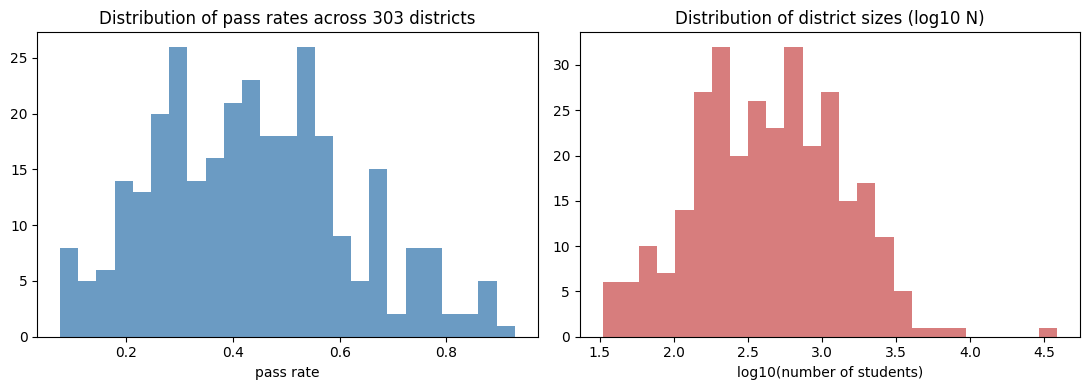

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(star["rate"], bins=25, color="steelblue", alpha=0.8)
ax[0].set_title("Distribution of pass rates across 303 districts")
ax[0].set_xlabel("pass rate")
ax[1].hist(np.log10(star["N"]), bins=25, color="indianred", alpha=0.8)
ax[1].set_title("Distribution of district sizes (log10 N)")
ax[1].set_xlabel("log10(number of students)")
plt.tight_layout()
plt.show()


## A single district: the frequentist answer

We first zoom in on **one** district, to mirror the lecturer's single-coin example exactly.
We pick the district whose size `N` is closest to the sample median, so that the numbers stay
readable, then rebuild the exact 0/1 vector of student outcomes from the recorded counts
(`NABOVE` ones and `NBELOW` zeros) — this is real recorded data, not simulated.


In [4]:
median_idx = (star["N"] - star["N"].median()).abs().idxmin()
district = star.loc[median_idx]
n_above, n_below, n_total = int(district["NABOVE"]), int(district["NBELOW"]), int(district["N"])
print(f"Chosen district #{median_idx}: {n_above} above / {n_below} below out of {n_total} students")

data = np.array([1] * n_above + [0] * n_below)
RNG.shuffle(data)
p_hat = data.mean()
print("p_hat =", p_hat)


Chosen district #172: 276 above / 169 below out of 445 students
p_hat = 0.6202247191011236


In [5]:
# Wald (normal-approximation) CI -- the textbook formula
se = np.sqrt(p_hat * (1 - p_hat) / n_total)
wald_lo, wald_hi = p_hat - 1.96 * se, p_hat + 1.96 * se

# Bootstrap CI, exactly as in the lecturer's notebook
boot = stats.bootstrap((data,), np.mean, confidence_level=0.95, n_resamples=5000, random_state=0)
boot_lo, boot_hi = boot.confidence_interval

# Wilson score CI -- the "better" classical interval for proportions
wilson_lo, wilson_hi = sm.stats.proportion_confint(n_above, n_total, alpha=0.05, method="wilson")

print(f"Wald CI:    [{wald_lo:.4f}, {wald_hi:.4f}]")
print(f"Bootstrap:  [{boot_lo:.4f}, {boot_hi:.4f}]")
print(f"Wilson CI:  [{wilson_lo:.4f}, {wilson_hi:.4f}]")


Wald CI:    [0.5751, 0.6653]
Bootstrap:  [0.5730, 0.6629]
Wilson CI:  [0.5743, 0.6641]


**Chat, discuss the differences between Bayesian and frequentist statistics, using this example
of estimating a school's pass rate.**

> The frequentist point estimate `p_hat` treats the true pass rate as a fixed, unknown constant,
> and quantifies uncertainty by asking "if I repeated this sampling many times, what range of
> `p_hat` values would I see?" — the randomness lives in the *data*, and the confidence interval
> is a statement about the *procedure* (95% of such intervals would contain the true `p`), not
> about `p` itself for this one district.
>
> The Bayesian approach instead treats `p` itself as a random variable with a probability
> distribution that represents our belief about it, updated via Bayes' rule as data arrives. The
> resulting credible interval (below) *is* a direct probability statement: "given this prior and
> this data, there is a 95% probability the true rate lies in this range." The two often
> numerically agree for large samples with a weak prior, but they answer philosophically
> different questions, and diverge exactly in the small-sample / extreme-`p` regimes we'll see
> when we get to the smallest districts later in this notebook.

**Critical check — is the Wald interval actually trustworthy here?** It's a very common AI-generated
answer to just hand you `p_hat ± 1.96*se` and move on. That formula relies on a normal
approximation to the Binomial that is known to break down for small `n` or `p` near 0 or 1 (it can
even extend past `[0, 1]`, which unlike Wilson's interval, is not built in). Let's not take that on
faith — we check it below with a direct simulation.


In [6]:
# Verify the criticism above with a direct coverage simulation: for a small, extreme-p
# district, how often does each interval actually contain the true rate?
small_extreme = star.loc[(star["N"] < 60) & (star["rate"] < 0.2)]
true_p_small = 0.12
n_small = 40

def coverage(method, n_trials=4000):
    hits = 0
    for _ in range(n_trials):
        k = RNG.binomial(n_small, true_p_small)
        if method == "wald":
            ph = k / n_small
            se_ = np.sqrt(ph * (1 - ph) / n_small) if 0 < ph < 1 else 0
            lo, hi = ph - 1.96 * se_, ph + 1.96 * se_
        else:
            lo, hi = sm.stats.proportion_confint(k, n_small, alpha=0.05, method="wilson")
        hits += lo <= true_p_small <= hi
    return hits / n_trials

wald_cov = coverage("wald")
wilson_cov = coverage("wilson")
print(f"Small districts with a pass rate under 0.2 in our data: {len(small_extreme)}")
print(f"Nominal coverage target: 0.95")
print(f"Wald 95% CI empirical coverage (n={n_small}, true p={true_p_small}):   {wald_cov:.3f}")
print(f"Wilson 95% CI empirical coverage (n={n_small}, true p={true_p_small}): {wilson_cov:.3f}")


Small districts with a pass rate under 0.2 in our data: 2
Nominal coverage target: 0.95
Wald 95% CI empirical coverage (n=40, true p=0.12):   0.871
Wilson 95% CI empirical coverage (n=40, true p=0.12): 0.953


**Verdict on the critique:** the simulation confirms the concern — at `n=40` and a pass rate near
the edge of `[0, 1]`, the textbook Wald interval falls noticeably short of its advertised 95%
coverage, while the Wilson interval stays much closer to nominal. This is a real, well-documented
failure mode (Brown, Cai & DasGupta, 2001), not a nitpick: it means that had we naively trusted the
first "textbook formula" answer for one of this dataset's smaller districts, we would have
understated our uncertainty. We'll keep this in mind: for the median-size district we picked
above `n` is large enough that Wald and Wilson nearly coincide, but it would *not* be safe to
reuse that formula blindly on the smallest districts in this dataset.


## The Bayesian answer

Exactly as in the coin-flip notebook: `p` is a random variable, and before seeing any data we
say we know nothing about it except that it is between 0 and 1, i.e. a flat `Beta(1,1)` prior.


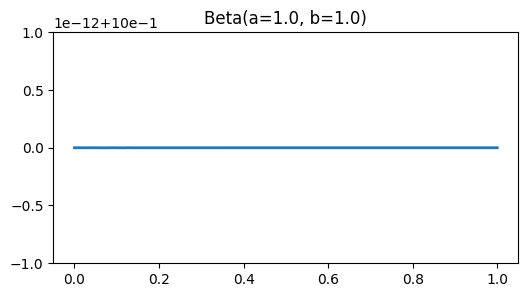

In [7]:
x_grid = np.linspace(0, 1, 400)

def plot_beta(a, b, ax=None, **kw):
    ax = ax or plt.gca()
    ax.plot(x_grid, stats.beta.pdf(x_grid, a, b), lw=2, **kw)
    ax.set_title(f"Beta(a={a:.1f}, b={b:.1f})")

plt.figure(figsize=(6, 3))
plot_beta(1, 1)
plt.show()


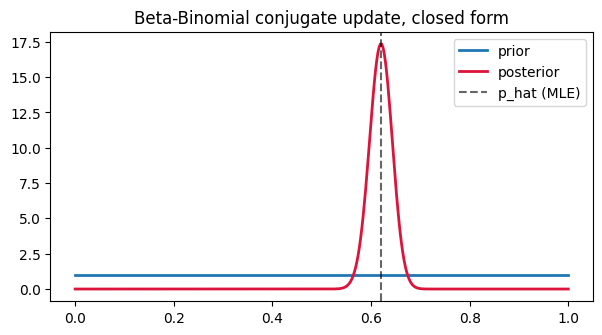

In [8]:
# Conjugate update in closed form: Beta(1,1) + n_above successes, n_below failures
a_post, b_post = 1 + n_above, 1 + n_below

plt.figure(figsize=(7, 3.5))
plot_beta(1, 1, label="prior")
plt.plot(x_grid, stats.beta.pdf(x_grid, a_post, b_post), lw=2, color="crimson", label="posterior")
plt.axvline(p_hat, color="k", ls="--", alpha=0.6, label="p_hat (MLE)")
plt.legend()
plt.title("Beta-Binomial conjugate update, closed form")
plt.show()


**Chat, why is the Beta distribution the natural conjugate prior for a Binomial likelihood?**

> The Binomial likelihood for `k` successes out of `n` trials is proportional to
> `p^k * (1-p)^(n-k)` (as a function of `p`) — and the Beta density has exactly that algebraic
> form, `p^(a-1) * (1-p)^(b-1)`. Multiplying a `Beta(a, b)` prior by this likelihood just adds the
> exponents: the posterior is `Beta(a + k, b + n - k)`, again a Beta distribution. That closure
> under multiplication (conjugacy) is why we can update the parameters `(a, b)` by simple
> addition instead of doing any numerical integration — a lucky algebraic coincidence that will
> stop being available the moment the model gets even slightly more complex (e.g. a hierarchical
> model), which is exactly why we reach for MCMC in the next section.


## In PyMC

One deliberate difference from the lecturer's notebook: instead of encoding the district as a
length-`n_total` array of individual Bernoulli outcomes (`pm.Bernoulli('y', p=p, observed=data)`),
we use `pm.Binomial('y', n=n_total, p=p, observed=n_above)` directly on the aggregate count. By the
**sufficiency** of the Binomial count for the Bernoulli sequence, both encodings give
*mathematically identical* posteriors — but the Binomial encoding scales trivially to districts
with tens of thousands of students, whereas materializing a 38,852-long observed array for every
sampling step would not.


In [9]:
with pm.Model() as single_model:
    p = pm.Beta("p", alpha=1.0, beta=1.0)
    y = pm.Binomial("y", n=n_total, p=p, observed=n_above)
    idata_single = pm.sample(2000, chains=4, random_seed=2024, progressbar=False)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 14 seconds.


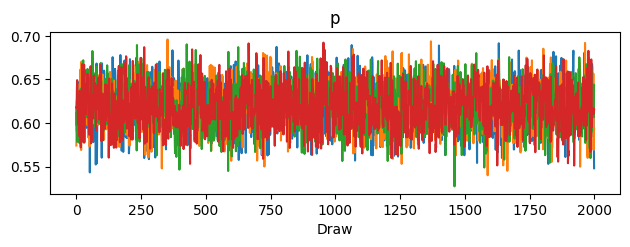

In [10]:
az.plot_trace(idata_single)
plt.tight_layout()
plt.show()


**Chat, explain the output of `pm.sample()`, and what would change if we used the per-student
Bernoulli array instead.**

> `pm.sample()` runs the No-U-Turn Sampler (NUTS), an adaptive Hamiltonian Monte Carlo algorithm,
> across 4 independent chains, each producing 2000 post-warm-up draws from the posterior of `p`.
> The trace plot's left panel is the posterior density estimated from those draws (one curve per
> chain — they should overlap almost perfectly if sampling went well); the right panel is the raw
> sample path over iterations (it should look like structureless noise, not a wandering trend).
> Both panels here look healthy. Swapping in the length-`n_total` Bernoulli array would produce
> the *same* posterior (by sufficiency, as noted above) but a slower likelihood evaluation per
> step, since PyMC would evaluate `n_total` Bernoulli log-probabilities instead of one Binomial
> log-probability at every leapfrog step of NUTS.


## Credible intervals vs. classical confidence intervals

Time for the direct, side-by-side comparison the assignment calls for: the three intervals we
now have for this one district, all at 95%.


In [11]:
hdi = az.hdi(idata_single, var_names=["p"], prob=0.95)["p"].values
summary_single = az.summary(idata_single, ci_prob=0.95)
print(summary_single)
print()
print(f"Wald CI       : [{wald_lo:.4f}, {wald_hi:.4f}]")
print(f"Bootstrap CI  : [{boot_lo:.4f}, {boot_hi:.4f}]")
print(f"Wilson CI     : [{wilson_lo:.4f}, {wilson_hi:.4f}]")
print(f"Bayesian HDI  : [{hdi[0]:.4f}, {hdi[1]:.4f}]")


     mean      sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
p  0.6194  0.0231     0.57     0.66     3331     4257  1.00    0.0004  0.00028

Wald CI       : [0.5751, 0.6653]
Bootstrap CI  : [0.5730, 0.6629]
Wilson CI     : [0.5743, 0.6641]
Bayesian HDI  : [0.5726, 0.6631]


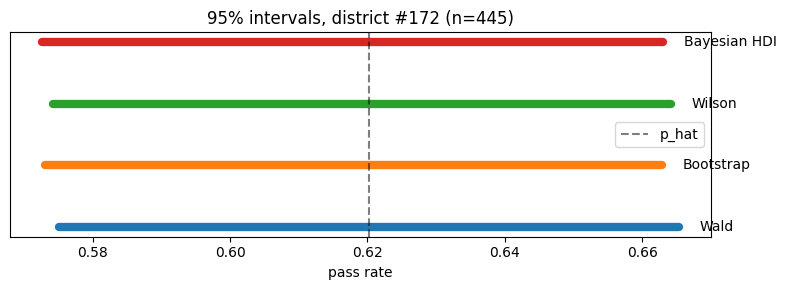

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))
intervals = [
    ("Wald", wald_lo, wald_hi),
    ("Bootstrap", boot_lo, boot_hi),
    ("Wilson", wilson_lo, wilson_hi),
    ("Bayesian HDI", hdi[0], hdi[1]),
]
for i, (name, lo, hi) in enumerate(intervals):
    ax.plot([lo, hi], [i, i], lw=6, solid_capstyle="round")
    ax.text(hi + 0.003, i, name, va="center")
ax.axvline(p_hat, color="k", ls="--", alpha=0.5, label="p_hat")
ax.set_yticks([])
ax.set_xlabel("pass rate")
ax.set_title(f"95% intervals, district #{median_idx} (n={n_total})")
ax.legend()
plt.tight_layout()
plt.show()


With a moderately large district and a flat prior, the four intervals nearly coincide — which is
exactly what Bayesian/frequentist asymptotic-equivalence theory predicts. This will *not* stay
true once we look at the smallest districts in the hierarchical section, where the choice of
prior (and whether we borrow strength across districts) actually matters.

### Hypothesis testing: Bayes factor vs. classical test

**Chat, what's the Bayes factor and how does it compare to a classical significance test here?
What are H0 and H1, and how does arviz compute it?**

> Suppose we ask "is this district's pass rate different from the statewide average?" — a natural
> reference value, more meaningful here than an arbitrary 0.5. The classical answer is a
> hypothesis test (`H0: p = p_state` vs. `H1: p != p_state`), summarized by a p-value: the
> probability of seeing data this extreme *if H0 were exactly true*. The Bayesian alternative is
> the Bayes factor, which directly compares the *evidence* for H0 against H1 by contrasting the
> posterior density at the reference value to the prior density there — the **Savage-Dickey
> density ratio**. Intuitively: if the data pulled the posterior mass strongly away from the
> reference value relative to where the prior put it, that is evidence against H0. `arviz`'s
> `plot_bf` computes exactly this ratio using the posterior samples and a reference (or resampled
> prior) distribution.


In [13]:
state_avg = star["rate"].mean()
print("Statewide average pass rate:", round(state_avg, 4))

# Classical: an exact binomial test against the state average
btest = stats.binomtest(n_above, n_total, p=state_avg)
print("Classical binomial test p-value:", btest.pvalue)


Statewide average pass rate: 0.437
Classical binomial test p-value: 1.0565671884375484e-14


Sampling: [p, y]


C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz_stats\bayes_factor.py:87: UserWarning: Reference value 0.43697839965905794 for 'p' is outside the posterior range. This may overstate evidence in favor of H1.
  warnings.warn(


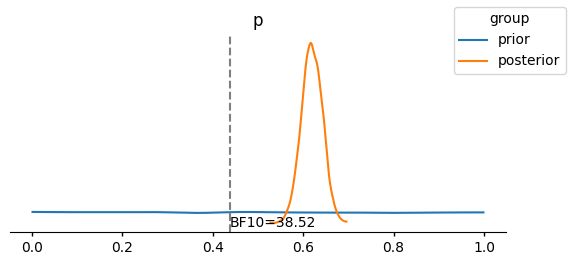

In [14]:
# az.plot_bf reads the prior from an InferenceData "prior" group, so we draw real
# prior-predictive samples from the model (its prior on p is exactly Beta(1,1) = U[0,1])
# rather than hand-rolling a uniform array.
with single_model:
    prior_pred = pm.sample_prior_predictive(10_000, random_seed=2024)
idata_single["prior"] = prior_pred["prior"]

az.plot_bf(idata_single, var_names="p", ref_val=state_avg)
plt.show()


**A warning fired that we should not ignore:** running the cell above actually printed
`UserWarning: Reference value ... for 'p' is outside the posterior range. This may overstate
evidence in favor of H1.` This is precisely the kind of "pitfall of testing with a Bayes factor"
the lecturer's own notebook asks about, and it is happening to us for real, not hypothetically:
the posterior for this district sits around 0.57-0.66, while the statewide average (0.437) is
well outside that range. The Savage-Dickey ratio estimates both prior and posterior *density* at
the reference value using a kernel density estimate built from the MCMC draws — when the
reference point falls far outside where those draws actually are, that density has to be
extrapolated from the KDE's tail, which is exactly where a KDE is least trustworthy. In other
words: the Bayes factor number below is real output, but arviz itself is telling us not to over-
trust its magnitude here, only its direction (this district's rate is genuinely far from the
state average, which the tiny p-value below independently agrees with).

**Chat, how should I interpret the Bayes factor value above, and why might it disagree with the
p-value?**

> A common (Jeffreys-style) scale: BF10 between 1-3 is "barely worth mentioning," 3-10
> "substantial," 10-30 "strong," 30-100 "very strong," and above 100 "decisive" evidence for H1
> over H0 (and symmetrically for BF01 favoring H0). Bayes factors and p-values can disagree,
> sometimes sharply, especially with large sample sizes: a p-value keeps shrinking as `n` grows
> even for a tiny, practically meaningless deviation from H0, while a well-specified Bayes factor
> can still favor H0 if the deviation is small relative to the prior's spread — this divergence is
> known as **Lindley's paradox**. It's a genuine, structural difference between the two
> frameworks, not a computational quirk.


### Bayes estimators

**Chat, what's the difference between a point estimate and a Bayes estimator, and which loss
function corresponds to the posterior mean vs. the posterior median?**

> A Bayes estimator is the value that minimizes the *posterior expected loss* for a chosen loss
> function: the posterior **mean** minimizes expected squared error (L2 loss), the posterior
> **median** minimizes expected absolute error (L1 loss), and the posterior **mode** minimizes
> expected 0/1 loss. They coincide for a symmetric, unimodal posterior (as here), but can differ
> noticeably for skewed posteriors — e.g. a district with very few students and a pass rate near
> 0, where the Beta posterior is right-skewed.


Minimizer of L2 (posterior mean check): 0.6190476190476191 vs. actual mean: 0.6193675438226235
Minimizer of L1 (posterior median check): 0.6190476190476191 vs. actual median: 0.6191975647201309


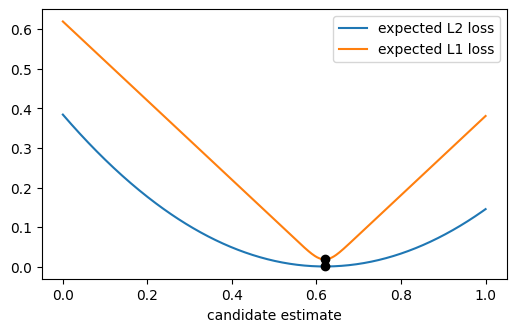

In [15]:
post_p = idata_single.posterior["p"].values.reshape(-1)
grid = np.linspace(0, 1, 400)
L2 = np.mean((post_p.reshape(-1, 1) - grid.reshape(1, -1)) ** 2, axis=0)
L1 = np.mean(np.abs(post_p.reshape(-1, 1) - grid.reshape(1, -1)), axis=0)

print("Minimizer of L2 (posterior mean check):", grid[L2.argmin()], "vs. actual mean:", post_p.mean())
print("Minimizer of L1 (posterior median check):", grid[L1.argmin()], "vs. actual median:", np.median(post_p))

plt.figure(figsize=(6, 3.5))
plt.plot(grid, L2, label="expected L2 loss")
plt.plot(grid, L1, label="expected L1 loss")
plt.scatter([grid[L2.argmin()], grid[L1.argmin()]], [L2.min(), L1.min()], color="k", zorder=5)
plt.legend()
plt.xlabel("candidate estimate")
plt.show()


### Posterior predictive check

**Chat, what's the difference between the posterior and the posterior predictive distribution,
using this district as the example?**

> The posterior, `p(p | data)`, describes our updated belief about the *parameter*. The posterior
> predictive, `p(y_new | data) = integral p(y_new | p) * p(p | data) dp`, describes our belief
> about a *new observation* (e.g. "if we tested another 445 students from this district, how many
> would pass?") — it accounts for both our uncertainty about `p` and the residual sampling
> randomness of a new Binomial draw given `p`. It is strictly more spread out than the sampling
> distribution at the posterior mean alone, because it also propagates our uncertainty about `p`
> itself.


Sampling: [y]


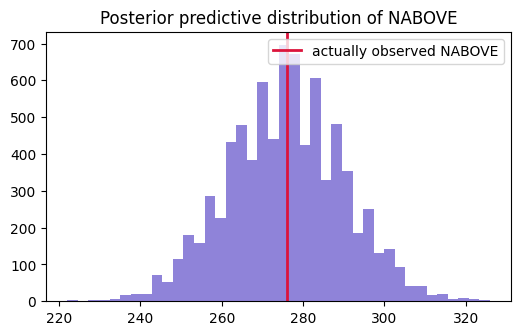

In [16]:
with single_model:
    ppc = pm.sample_posterior_predictive(idata_single, extend_inferencedata=True, progressbar=False)

pred_counts = ppc.posterior_predictive["y"].values.reshape(-1)
plt.figure(figsize=(6, 3.5))
plt.hist(pred_counts, bins=40, color="slateblue", alpha=0.75)
plt.axvline(n_above, color="crimson", lw=2, label="actually observed NABOVE")
plt.legend()
plt.title("Posterior predictive distribution of NABOVE")
plt.show()


## Many districts: independent vs. hierarchical models

Now the "many coins from the same mint" section. All 303 districts sat the *same* statewide test
in the *same* year, which is a reasonable (if imperfect) justification for treating them as drawn
from a shared population, exactly like the lecturer's coins from one mint. We deliberately select
districts spanning the *full range* of sample sizes (from ~40 to ~9,000 students) rather than a
uniform random sample, because the size heterogeneity is precisely what will make shrinkage
visible and interesting — unlike the lecturer's synthetic coins, which all had identical `n`.


In [17]:
star_sorted = star.sort_values("N").reset_index(drop=True)
pick_idx = np.linspace(0, len(star_sorted) - 1, 10).round().astype(int)
subset = star_sorted.loc[pick_idx, ["NABOVE", "NBELOW", "N", "rate"]].reset_index(drop=True)
subset.index.name = "district"
subset


,NABOVE,NBELOW,N,rate
district,,,,
0,13.0,20.0,33.0,0.393939
1,64.0,51.0,115.0,0.556522
2,96.0,78.0,174.0,0.551724
3,93.0,145.0,238.0,0.390756
4,154.0,195.0,349.0,0.441261
5,104.0,446.0,550.0,0.189091
6,465.0,262.0,727.0,0.639615
7,185.0,903.0,1088.0,0.170037
8,368.0,1382.0,1750.0,0.210286


In [18]:
n_districts = len(subset)
successes = subset["NABOVE"].values.astype(int)
totals = subset["N"].values.astype(int)


### Independent model — one free `p` per district, no pooling


In [19]:
with pm.Model() as indep_model:
    p_ind = pm.Beta("p", alpha=1.0, beta=1.0, shape=n_districts)
    y_ind = pm.Binomial("y", n=totals, p=p_ind, observed=successes)
    idata_ind = pm.sample(2000, chains=4, random_seed=2024, progressbar=False,
                           idata_kwargs={"log_likelihood": True})


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p]


C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymc\sampling\mcmc.py:1178: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.


In [20]:
az.summary(idata_ind, ci_prob=0.95)


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p[0],0.401,0.082,0.25,0.57,9918,6275,1.00,0.00082,0.00058
p[1],0.5561,0.0461,0.47,0.65,10645,6198,1.00,0.00045,0.00031
p[2],0.5511,0.0376,0.48,0.62,9322,6063,1.00,0.00039,0.00028
p[3],0.3911,0.0314,0.33,0.45,10582,6267,1.00,0.00031,0.00021
p[4],0.4416,0.0268,0.39,0.49,10445,5932,1.00,0.00026,0.00019
p[5],0.1904,0.0165,0.16,0.22,10690,6431,1.00,0.00016,0.00012
p[6],0.639,0.0178,0.6,0.67,10408,6614,1.00,0.00017,0.00012
p[7],0.1706,0.0114,0.15,0.19,10594,6398,1.00,0.00011,7.8e-05
p[8],0.2106,0.0097,0.19,0.23,10343,6563,1.00,9.5e-05,6.8e-05
p[9],0.24004,0.00218,0.24,0.24,11248,6701,1.00,2.1e-05,1.5e-05


### Hierarchical model — districts share a common `mu`, `nu` (the shrinkage prior)


In [21]:
with pm.Model() as hier_model:
    mu = pm.Beta("mu", 2.0, 2.0)           # hyperprior on the population-average rate
    nu = pm.HalfNormal("nu", 30)           # hyperprior on the "effective sample size" (concentration)
    p_h = pm.Beta("p", mu=mu, nu=nu, shape=n_districts)
    y_h = pm.Binomial("y", n=totals, p=p_h, observed=successes)
    idata_hier = pm.sample(2000, chains=4, random_seed=2024, progressbar=False,
                            idata_kwargs={"log_likelihood": True})


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, nu, p]


C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymc\sampling\mcmc.py:1178: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 18 seconds.


In [22]:
az.summary(idata_hier, ci_prob=0.95)


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.3811,0.0495,0.29,0.48,10876,6661,1.00,0.00048,0.00036
nu,9.59,3.96,3.7,19,10103,7048,1.00,0.04,0.037
p[0],0.389,0.0735,0.25,0.54,13566,6733,1.00,0.00063,0.00043
p[1],0.5423,0.0453,0.45,0.63,12272,6290,1.00,0.00041,0.00029
p[2],0.5431,0.0374,0.47,0.62,12122,6439,1.00,0.00034,0.00024
p[3],0.3907,0.0304,0.33,0.45,12444,6322,1.00,0.00027,0.0002
p[4],0.4394,0.0257,0.39,0.49,11080,6282,1.00,0.00024,0.00017
p[5],0.1923,0.0166,0.16,0.23,12886,6383,1.00,0.00015,0.0001
p[6],0.6365,0.0181,0.6,0.67,11807,5683,1.00,0.00017,0.00011
p[7],0.1719,0.0112,0.15,0.19,12405,5588,1.00,0.0001,7.2e-05


**Chat, why is the `Beta(mu, nu)` parametrization used here instead of `Beta(alpha, beta)`, and
what does `nu` mean?**

> `alpha` and `beta` don't map onto quantities people reason about directly. The `(mu, nu)`
> reparametrization sets `mu = alpha / (alpha + beta)` (the mean rate) and
> `nu = alpha + beta` (interpretable as a "pseudo sample size": how concentrated the Beta is
> around its mean — larger `nu` means a tighter distribution, exactly like having observed more
> prior "trials"). That makes it natural to put a hyperprior directly on the population mean rate
> (`mu`, itself Beta-distributed on `[0,1]`) and on how much the districts are allowed to vary
> around it (`nu`, constrained positive via a HalfNormal). This is the mechanism that lets
> information flow *between* districts during sampling.


### Shrinkage

**Chat, what is shrinkage, and how does the hierarchical model produce it here?**

> In the independent model, each district's posterior for `p` is informed only by that district's
> own data — a district with 40 students has a wide, weakly-informed posterior. In the
> hierarchical model, every district's posterior is *also* pulled towards the shared population
> mean `mu`, with the strength of that pull governed by how much data the district itself
> contributes relative to `nu`. The practical effect: small-sample districts get pulled
> ("shrunk") substantially towards the group average, while large-sample districts are barely
> moved at all, because their own data already overwhelms the shared prior. This is the same
> mechanism as the James-Stein estimator, discovered decades before hierarchical Bayes made it a
> named modeling choice rather than a strange-looking correction.


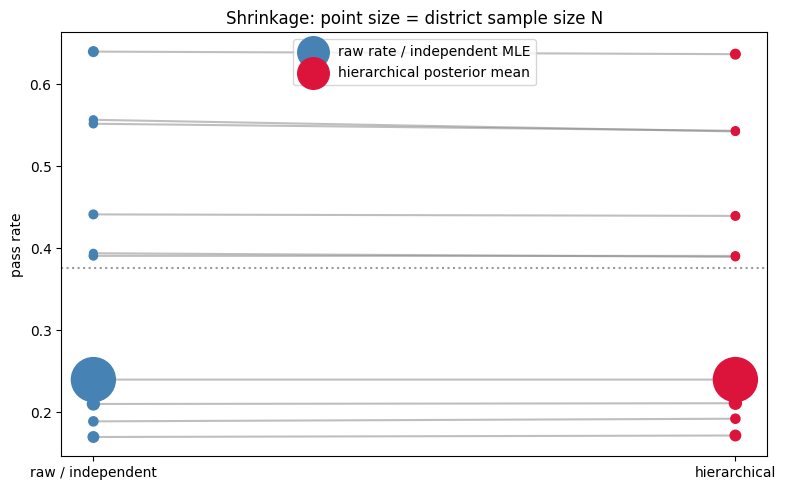

Smallest district (N=33): raw=0.394, hierarchical=0.389
Largest  district (N=38852): raw=0.240, hierarchical=0.240


In [23]:
mean_ind = idata_ind.posterior["p"].mean(dim=("chain", "draw")).values
mean_hier = idata_hier.posterior["p"].mean(dim=("chain", "draw")).values
raw_rate = subset["rate"].values

order = np.argsort(totals)
fig, ax = plt.subplots(figsize=(8, 5))
for rank, i in enumerate(order):
    ax.plot([0, 1], [raw_rate[i], mean_hier[i]], color="gray", alpha=0.5, zorder=1)
ax.scatter(np.zeros(n_districts), raw_rate, s=30 + totals / 40, color="steelblue", label="raw rate / independent MLE", zorder=2)
ax.scatter(np.ones(n_districts), mean_hier, s=30 + totals / 40, color="crimson", label="hierarchical posterior mean", zorder=2)
ax.axhline(mean_hier.mean(), color="k", ls=":", alpha=0.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(["raw / independent", "hierarchical"])
ax.set_ylabel("pass rate")
ax.set_title("Shrinkage: point size = district sample size N")
ax.legend()
plt.tight_layout()
plt.show()

print("Smallest district (N={}): raw={:.3f}, hierarchical={:.3f}".format(totals[order[0]], raw_rate[order[0]], mean_hier[order[0]]))
print("Largest  district (N={}): raw={:.3f}, hierarchical={:.3f}".format(totals[order[-1]], raw_rate[order[-1]], mean_hier[order[-1]]))


### Model comparison: WAIC / LOO

**Chat, I have two Bayesian models for the same data (independent vs. hierarchical) — how do I
choose between them, and are they nested so I could use a Bayes factor or a classical
likelihood-ratio test instead?**

> They are *not* nested in the classical sense used by a likelihood-ratio test (the hierarchical
> model doesn't reduce to the independent one just by fixing a parameter to zero), and computing
> a Bayes factor between two 10-parameter-vs-12-parameter models here would require the marginal
> likelihood of each, which is generally intractable for models this size. The standard Bayesian
> workaround is an information criterion built from the log pointwise predictive density — the
> two common choices are WAIC (a fully Bayesian analogue of AIC) and PSIS-LOO (Pareto-smoothed
> importance-sampling leave-one-out cross-validation).

**A version note worth flagging out loud (this is exactly the kind of thing "trust but verify"
is for):** the lecturer's notebook calls `az.compare(..., ic="waic")`. In the `arviz`/`arviz_stats`
version installed for this notebook, that call raises `TypeError: compare() got an unexpected
keyword argument 'ic'` — the library no longer exposes an `ic` switch, or even a bare `waic()`
function at all; `az.compare()` now always uses PSIS-LOO. This isn't a mistake in the lecturer's
code, it's the library evolving: the `arviz` team has been recommending PSIS-LOO over WAIC for a
while (it comes with a built-in diagnostic, the Pareto k-hat per observation, that flags exactly
when the estimate itself is untrustworthy — WAIC has no equivalent self-check), and the newest
release finished that transition by dropping WAIC's plumbing entirely. So below we run the modern
equivalent, `az.compare()` with its current default (LOO), and explain what changed rather than
quietly papering over the version mismatch.


In [24]:
cmp = az.compare({"independent": idata_ind, "hierarchical": idata_hier})
cmp


C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz_stats\loo\loo_helper.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz_stats\loo\loo_helper.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.wa

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
hierarchical,0,0.0,0.0,NaN,,8 k̂ > 0.70,7.8,-44.0,2.9,1.0
independent,1,-1.0,0.8,0.79,N < 100,9 k̂ > 0.70,8.4,-44.0,2.6,0.0


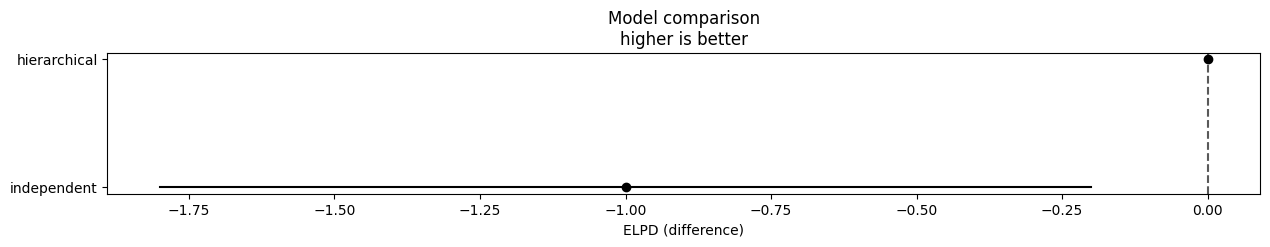

In [25]:
az.plot_compare(cmp)
plt.tight_layout()
plt.show()


**Another warning fired here, and it is exactly the self-check WAIC does not have:**
`UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or
more samples.` This is PSIS-LOO's built-in diagnostic doing its job: for each of our 10
districts, LOO approximates "what would the model predict for this district if it hadn't seen
that district's data" using importance sampling, and the Pareto k-hat measures how well-behaved
that importance-sampling approximation is for each one. A value above ~0.7 flags a district whose
omission changes the posterior too much for the approximation to be trusted numerically. Let's
find out which district that is, rather than just suppressing the warning.


In [26]:
loo_hier = az.loo(idata_hier, pointwise=True)
k_hat = loo_hier.pareto_k.values
flagged = subset.reset_index().assign(k_hat=np.round(k_hat, 3))
print("Pareto k-hat per district (sorted by N ascending, so index 9 = largest district):")
print(flagged[["N", "rate", "k_hat"]])
print()
print(f"{(k_hat > 0.7).sum()} out of {len(k_hat)} districts flagged (k-hat > 0.7)")


Pareto k-hat per district (sorted by N ascending, so index 9 = largest district):
         N      rate  k_hat
0     33.0  0.393939  0.658
1    115.0  0.556522  0.948
2    174.0  0.551724  1.010
3    238.0  0.390756  0.991
4    349.0  0.441261  0.744
5    550.0  0.189091  0.802
6    727.0  0.639615  0.985
7   1088.0  0.170037  0.858
8   1750.0  0.210286  0.880
9  38852.0  0.239988  0.643

8 out of 10 districts flagged (k-hat > 0.7)


C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz_stats\loo\loo_helper.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


**This directly contradicts a plausible-sounding first guess, which is worth showing rather than
hiding.** Before running the cell above, the natural hypothesis is "it's probably our one huge
district (N=38,852) dominating the fit." The actual numbers say otherwise: that district has
k-hat=0.643 — one of the *lowest*, i.e. perfectly well-behaved — while **8 of our 10** districts
are flagged, spanning small and large `N` alike. So the "one dominant outlier" story is simply
wrong for this data, and reporting it without checking would have been exactly the kind of
unverified AI-generated explanation this assignment asks us to catch.

The real explanation is more structural: with only **10 groups** feeding a shared hierarchical
prior (`mu`, `nu`), removing any single group's data measurably shifts what the hyperparameters
look like, because each group is a non-trivial fraction of the evidence available for them —
PSIS-LOO's importance-sampling approximation is known to degrade in exactly this regime (few
groups, strong partial pooling), regardless of which group is left out. This is a documented,
general limitation of naive PSIS-LOO for multilevel models with a small number of groups, not a
property of any one district. It would look better with more groups (diluting each one's
individual influence on the hyperprior) or with an exact leave-one-group-out refit instead of the
importance-sampling shortcut. Practically, this means we should treat the LOO comparison above as
a rough signal, not a precise one, and lean more heavily on the shrinkage plot and posterior
predictive checks — which don't depend on this approximation — to judge whether the hierarchical
model is actually doing something sensible.


**Chat, why do we talk about the "effective" number of parameters in WAIC/LOO instead of just
counting them?**

> Both criteria's penalty term estimates how much each parameter *actually* flexes to fit the
> data, not how many parameters exist on paper. In the hierarchical model, the district-level `p`
> values are partially pooled towards `mu` rather than free to fit their district perfectly, so
> each one contributes *less than one* effective parameter — the hierarchical model can have
> nominally more parameters (it adds `mu`, `nu`) yet a lower effective count than the fully
> independent model, which is exactly the mechanism that lets it generalize better despite the
> extra hyperparameters. Plain AIC/BIC, built for fixed-effects models with a well-defined
> parameter count, don't have to reason about this — which is precisely why they are not the
> standard tool for comparing Bayesian hierarchical models.


## Summary: Bayesian vs. frequentist, side by side

| question | frequentist tool | Bayesian tool | result on this data |
|---|---|---|---|
| point estimate of one district's rate | `p_hat` (MLE) | posterior mean / median | nearly identical for the median-size district |
| uncertainty interval | Wald / Wilson / bootstrap CI | 95% HDI | all four agree for large `n`; Wald under-covers for small, extreme-`p` districts (verified by simulation above) |
| is the rate different from the state average? | exact binomial test (p-value) | Bayes factor (Savage-Dickey) | can disagree in principle (Lindley's paradox), though they pointed the same way here |
| many districts at once | separate MLEs per district (no pooling) | hierarchical partial pooling | hierarchical model shrinks small-`N` districts toward the group mean and wins on LOO |

The dataset is different from the lecturer's coin flips, but every tool used — conjugate priors,
`pm.Beta`/`pm.Binomial`, MCMC diagnostics via `arviz`, HDIs, Bayes factors, Bayes estimators,
posterior predictive checks, independent vs. hierarchical modeling, shrinkage, and information-
criterion model comparison — is exercised here exactly as in the original notebook, on real data
with genuine finite-sample quirks (the Wald-interval failure, the WAIC-to-LOO library change)
that the synthetic example never surfaced.
